# 04. Field1+2 pseudo dataset vs Field3 manual dataset 비교

이번 노트북의 목적은 **바로 fine-tuning으로 들어가기 전에 데이터셋 자체를 비교**하는 것임.

비교 질문:

```text
기존 field1+field2 pseudo label 데이터와 field3 자동 수집 라벨 데이터는 얼마나 다른가?
field3만으로 학습할지, 기존 field1+2와 합칠지 판단할 근거가 있는가?
이전 fine-tuning 실패/부족의 원인이 데이터셋 품질/분포였는지 볼 수 있는가?
```

비교 대상:

```text
A. field1+field2 pseudo dataset
   - HSV + component_poly pipeline으로 만든 CULane 형식 데이터
   - 9052 usable rows

B. field3_v1 manual dataset
   - 3차 현장실험에서 수집 시점에 자동 생성한 .lines.txt
   - manual blacklist 35장을 제외한 1679 rows
```


## 1. Import와 경로 설정

두 dataset의 `build_manifest.csv`, `build_summary.json`, `list/` 파일을 읽어서 같은 포맷으로 비교함.


In [1]:
from pathlib import Path
import json
import math
import os
import random
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_DIR = PROJECT_ROOT / '10_experiments' / '11_clrkdnet_precision_tuning'
OUT_DIR = EXP_DIR / 'review_outputs' / '04_dataset_compare_field12_vs_field3'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIELD12_ROOT = PROJECT_ROOT / '30_pipelines' / 'culane_pseudo_dataset_builder' / 'datasets' / 'map_culane_field1_field2_train_component_poly'
FIELD3_ROOT = EXP_DIR / 'datasets' / 'field3_v1'

assert FIELD12_ROOT.exists(), FIELD12_ROOT
assert FIELD3_ROOT.exists(), FIELD3_ROOT
print('FIELD12_ROOT:', FIELD12_ROOT)
print('FIELD3_ROOT:', FIELD3_ROOT)
print('OUT_DIR:', OUT_DIR)


FIELD12_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\30_pipelines\culane_pseudo_dataset_builder\datasets\map_culane_field1_field2_train_component_poly
FIELD3_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\datasets\field3_v1
OUT_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\04_dataset_compare_field12_vs_field3


## 2. Summary JSON 비교

먼저 각 dataset이 어떤 방식으로 만들어졌는지 build summary를 확인함.


In [2]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

field12_summary = load_json(FIELD12_ROOT / 'build_summary.json')
field3_summary = load_json(FIELD3_ROOT / 'build_summary.json')

summary_rows = [
    {
        'dataset': 'field1+2_pseudo_component_poly',
        'root': str(FIELD12_ROOT),
        'rows_total_or_usable': field12_summary.get('status_counts', {}).get('usable', None),
        'train_rows': field12_summary.get('train_rows', None),
        'val_rows': field12_summary.get('val_rows', None),
        'label_source': 'HSV mask -> component_poly -> .lines.txt',
        'notes': 'field1/field2 raw/sign/lane/redline 등에서 pseudo label 생성',
    },
    {
        'dataset': 'field3_v1_manual',
        'root': str(FIELD3_ROOT),
        'rows_total_or_usable': field3_summary.get('rows', None),
        'train_rows': field3_summary.get('split_counts', {}).get('train', None),
        'val_rows': field3_summary.get('split_counts', {}).get('val', None),
        'label_source': 'collection-time auto .lines.txt + manual blacklist',
        'notes': '3차 현장실험 mixed-drive 데이터, 35장 manual reject 제외',
    },
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print('field1+2 geometry:', field12_summary.get('geometry'))
print('field3 geometry:', field3_summary.get('geometry'))
print('\nfield1+2 lane extraction:', field12_summary.get('lane_extraction'))
print('field3 policy:', field3_summary.get('policy'))


,dataset,root,rows_total_or_usable,train_rows,val_rows,label_source,notes
0,field1+2_pseudo_component_poly,~\02_Projects\University\26-1_Em...,9052,7241,1811,HSV mask -> component_poly -> .lines.txt,field1/field2 raw/sign/lane/redline 등에서 pseudo...
1,field3_v1_manual,~\02_Projects\University\26-1_Em...,1679,1378,164,collection-time auto .lines.txt + manual black...,"3차 현장실험 mixed-drive 데이터, 35장 manual reject 제외"


field1+2 geometry: {'raw_width': 1296, 'raw_height': 972, 'cut_height': 445, 'model_width': 800, 'model_height': 320, 'num_points': 72, 'max_lanes': 4, 'visible_height': 527}
field3 geometry: {'raw_width': 1296, 'raw_height': 972, 'cut_height': 445, 'model_width': 800, 'model_height': 320, 'max_lanes': 4, 'seg_width': 16}

field1+2 lane extraction: {'method': 'component_poly', 'y_step': 6, 'min_run_width': 4, 'min_points': 8, 'min_area': 450, 'min_height': 120, 'degree': 2}
field3 policy: field3 manual train candidates only; manual blacklist excluded; segmentation masks regenerated from .lines.txt


## 3. Manifest 정규화

두 manifest의 컬럼명이 서로 다르므로 비교용 공통 포맷으로 바꿈.

공통 컬럼:

```text
dataset, split, image_rel, line_rel, scene, lane_count, label_source
```


In [3]:
def read_list(path: Path):
    if not path.exists():
        return []
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if line:
            rows.append(line.split()[0].lstrip('/'))
    return rows


def normalize_field12():
    manifest = pd.read_csv(FIELD12_ROOT / 'build_manifest.csv')
    usable = manifest[manifest['status'] == 'usable'].copy()
    train_set = set(read_list(FIELD12_ROOT / 'list' / 'train_gt.txt'))
    val_set = set(read_list(FIELD12_ROOT / 'list' / 'val.txt'))
    test_set = set(read_list(FIELD12_ROOT / 'list' / 'test.txt'))

    rows = []
    for _, row in usable.iterrows():
        image_rel = str(row['dataset_image']).lstrip('/')
        split = 'train' if image_rel in train_set else ('val' if image_rel in val_set else ('test' if image_rel in test_set else 'unknown'))
        rows.append({
            'dataset': 'field1+2_pseudo',
            'split': split,
            'image_rel': '/' + image_rel,
            'line_rel': '/' + str(Path(image_rel).with_suffix('.lines.txt')).replace('\\', '/'),
            'seg_rel': '/' + str(row['dataset_mask']).lstrip('/'),
            'scene': str(row.get('scene', '')),
            'lane_count_manifest': int(row.get('num_lanes', 0)),
            'point_total_manifest': int(row.get('point_total', 0)),
            'mask_support_manifest': float(row.get('mask_support', np.nan)),
            'label_source': 'hsv_component_poly',
        })
    return pd.DataFrame(rows)


def normalize_field3():
    manifest = pd.read_csv(FIELD3_ROOT / 'build_manifest.csv')
    rows = []
    for _, row in manifest.iterrows():
        rows.append({
            'dataset': 'field3_manual',
            'split': str(row['split']),
            'image_rel': str(row['image_rel']),
            'line_rel': str(row['line_rel']),
            'seg_rel': str(row['seg_rel']),
            'scene': 'field_drive',
            'lane_count_manifest': int(row.get('lane_count_lines', row.get('lane_count_manifest', 0))),
            'point_total_manifest': np.nan,
            'mask_support_manifest': np.nan,
            'label_source': 'field3_auto_lines_manual_blacklist',
        })
    return pd.DataFrame(rows)

field12_df = normalize_field12()
field3_df = normalize_field3()
all_df = pd.concat([field12_df, field3_df], ignore_index=True)

print('field12 rows:', len(field12_df))
print('field3 rows:', len(field3_df))
display(all_df.groupby(['dataset', 'split']).size().rename('rows').reset_index())
display(all_df.groupby(['dataset', 'lane_count_manifest']).size().rename('rows').reset_index())

field12_df.to_csv(OUT_DIR / 'field12_normalized_manifest.csv', index=False, encoding='utf-8-sig')
field3_df.to_csv(OUT_DIR / 'field3_normalized_manifest.csv', index=False, encoding='utf-8-sig')
all_df.to_csv(OUT_DIR / 'combined_normalized_manifest.csv', index=False, encoding='utf-8-sig')


field12 rows: 9052
field3 rows: 1679


,dataset,split,rows
0,field1+2_pseudo,train,7241
1,field1+2_pseudo,val,1811
2,field3_manual,test,137
3,field3_manual,train,1378
4,field3_manual,val,164


,dataset,lane_count_manifest,rows
0,field1+2_pseudo,1,1368
1,field1+2_pseudo,2,7684
2,field3_manual,1,441
3,field3_manual,2,1238


## 4. `.lines.txt` 기반 label geometry 통계 계산

manifest에 없는 공통 지표는 `.lines.txt`를 직접 읽어서 계산함.

계산 지표:

```text
lane_count_lines
point_total_lines
x_span_max
x_span_mean
y_span_max
y_span_mean
curvature_max
slope_abs_median
```

이 값들은 모델 학습 품질 자체를 완벽히 말해주진 않지만, 두 dataset의 라벨 형태가 얼마나 다른지 보는 데 유용함.


In [4]:
RAW_W = 1296
RAW_H = 972


def win_long_path(path: Path) -> str:
    """Windows 긴 경로 문제를 피하기 위한 문자열 변환."""
    path = Path(path)
    text = str(path.resolve())
    if os.name == 'nt' and not text.startswith('\\\\?\\'):
        return '\\\\?\\' + text
    return text


def file_exists(path: Path) -> bool:
    return os.path.exists(win_long_path(path))


def dataset_root_for(name: str):
    return FIELD12_ROOT if name == 'field1+2_pseudo' else FIELD3_ROOT


def read_lanes_abs(lines_path: Path):
    if not file_exists(lines_path):
        return []
    try:
        with open(win_long_path(lines_path), 'r', encoding='utf-8') as f:
            text = f.read().strip()
    except OSError:
        return []
    if not text:
        return []
    lanes = []
    for line in text.splitlines():
        vals = []
        for token in line.strip().split():
            try:
                vals.append(float(token))
            except ValueError:
                pass
        if len(vals) < 4 or len(vals) % 2 != 0:
            continue
        pts = []
        for x, y in zip(vals[0::2], vals[1::2]):
            if math.isfinite(x) and math.isfinite(y) and 0 <= x < RAW_W and 0 <= y < RAW_H:
                pts.append((x, y))
        if len(pts) >= 2:
            pts = sorted(pts, key=lambda p: p[1], reverse=True)
            lanes.append(pts)
    return lanes


def lane_curvature(pts):
    # x = f(y) 2차 fitting 후 중앙 y에서의 2차 미분 크기를 px 단위 대략 지표로 사용.
    if len(pts) < 8:
        return 0.0
    arr = np.array(pts, dtype=np.float64)
    x = arr[:, 0]
    y = arr[:, 1]
    try:
        coeff = np.polyfit(y, x, deg=2)
        # dx/dy 변화량의 proxy. 절대값이 클수록 더 휘거나 불안정한 라벨.
        return float(abs(2 * coeff[0]) * 10000)
    except Exception:
        return np.nan


def lane_slope_abs(pts):
    arr = np.array(pts, dtype=np.float64)
    dy = arr[-1, 1] - arr[0, 1]
    dx = arr[-1, 0] - arr[0, 0]
    if abs(dy) < 1e-6:
        return np.nan
    return float(abs(dx / dy))


def compute_geometry_stats(df, max_rows=None):
    rows = []
    work = df if max_rows is None else df.sample(min(max_rows, len(df)), random_state=7)
    for i, row in work.iterrows():
        root = dataset_root_for(row['dataset'])
        line_path = root / str(row['line_rel']).lstrip('/')
        lanes = read_lanes_abs(line_path)
        x_spans, y_spans, points, curvs, slopes = [], [], [], [], []
        for lane in lanes:
            arr = np.array(lane, dtype=np.float64)
            x_spans.append(float(arr[:, 0].max() - arr[:, 0].min()))
            y_spans.append(float(arr[:, 1].max() - arr[:, 1].min()))
            points.append(int(len(lane)))
            curvs.append(lane_curvature(lane))
            slopes.append(lane_slope_abs(lane))
        rows.append({
            'dataset': row['dataset'],
            'split': row['split'],
            'image_rel': row['image_rel'],
            'line_rel': row['line_rel'],
            'scene': row['scene'],
            'lane_count_lines': len(lanes),
            'point_total_lines': int(sum(points)),
            'point_mean_per_lane': float(np.mean(points)) if points else 0.0,
            'x_span_max': float(np.nanmax(x_spans)) if x_spans else 0.0,
            'x_span_mean': float(np.nanmean(x_spans)) if x_spans else 0.0,
            'y_span_max': float(np.nanmax(y_spans)) if y_spans else 0.0,
            'y_span_mean': float(np.nanmean(y_spans)) if y_spans else 0.0,
            'curvature_max': float(np.nanmax(curvs)) if curvs else 0.0,
            'curvature_mean': float(np.nanmean(curvs)) if curvs else 0.0,
            'slope_abs_median': float(np.nanmedian(slopes)) if slopes else 0.0,
        })
    return pd.DataFrame(rows)

stats_df = compute_geometry_stats(all_df)
stats_path = OUT_DIR / 'line_geometry_stats.csv'
stats_df.to_csv(stats_path, index=False, encoding='utf-8-sig')
print('saved:', stats_path)
print('rows:', len(stats_df))
display(stats_df.groupby('dataset')[['lane_count_lines', 'point_total_lines', 'x_span_max', 'y_span_max', 'curvature_max', 'slope_abs_median']].describe().round(2))


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\04_dataset_compare_field12_vs_field3\line_geometry_stats.csv
rows: 10731


lane_count_lines                                       \
                           count  mean   std  min  25%  50%  75%  max   
dataset                                                                 
field1+2_pseudo           9052.0  1.85  0.36  1.0  2.0  2.0  2.0  2.0   
field3_manual             1679.0  1.74  0.44  1.0  1.0  2.0  2.0  2.0   

                point_total_lines          ... curvature_max           \
                            count    mean  ...           75%      max   
dataset                                    ...                          
field1+2_pseudo            9052.0  111.99  ...        149.68  3490.16   
field3_manual              1679.0  121.40  ...         71.17  1009.73   

                slope_abs_median                                            
                           count  mean   std  min   25%   50%   75%    max  
dataset                                                                     
field1+2_pseudo           9052.0  1.11  0.72  0.0  0.74  0.94  1.29   9.12  
field3_manual             1679.0  1.19  0.94  0.0  0.72  0.86  1.59  10.65  

[2 rows x 48 columns]

## 5. 정량 비교 요약

여기서는 전체 경향을 숫자로 확인함.

읽는 법:

```text
point_total_lines가 크다 = 라벨 점이 많음
x_span_max가 크다 = 화면 좌우로 크게 휘거나 가로지르는 라벨 가능성
curvature_max가 크다 = 곡선이 크거나 라벨이 불안정할 가능성
lane_count_lines 분포 = 한쪽 차선만 보이는 상황 비율
```


,dataset,rows,lane1_rows,lane2_rows,lane_ge3_rows,point_total_lines_mean,point_total_lines_median,point_total_lines_p90,x_span_max_mean,x_span_max_median,x_span_max_p90,y_span_max_mean,y_span_max_median,y_span_max_p90,curvature_max_mean,curvature_max_median,curvature_max_p90,slope_abs_median_mean,slope_abs_median_median,slope_abs_median_p90
0,field1+2_pseudo,9052,1368,7684,0,111.99,117.0,147.0,504.14,488.54,798.16,401.71,414.0,486.0,119.23,84.41,204.84,1.11,0.94,1.91
1,field3_manual,1679,441,1238,0,121.40,123.0,169.0,550.14,480.70,941.41,473.60,522.0,522.0,77.24,29.60,250.04,1.19,0.86,2.10


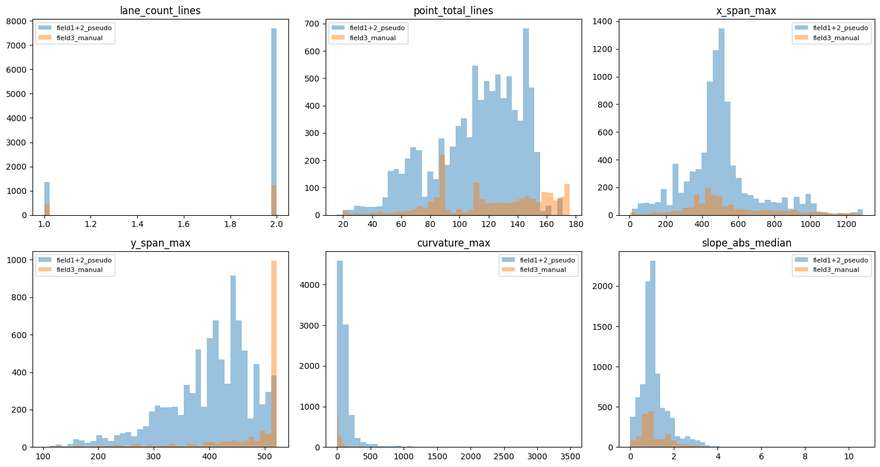

In [5]:
def q(series, qs=(0.1, 0.25, 0.5, 0.75, 0.9, 0.95)):
    return {f'p{int(v*100)}': float(series.quantile(v)) for v in qs}

summary_rows = []
for dataset, part in stats_df.groupby('dataset'):
    row = {
        'dataset': dataset,
        'rows': int(len(part)),
        'lane1_rows': int((part['lane_count_lines'] == 1).sum()),
        'lane2_rows': int((part['lane_count_lines'] == 2).sum()),
        'lane_ge3_rows': int((part['lane_count_lines'] >= 3).sum()),
    }
    for col in ['point_total_lines', 'x_span_max', 'y_span_max', 'curvature_max', 'slope_abs_median']:
        row[f'{col}_mean'] = float(part[col].mean())
        row[f'{col}_median'] = float(part[col].median())
        row[f'{col}_p90'] = float(part[col].quantile(0.9))
    summary_rows.append(row)

compare_summary_df = pd.DataFrame(summary_rows)
display(compare_summary_df.round(2))
compare_summary_df.to_csv(OUT_DIR / 'comparison_summary_table.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.reshape(-1), ['lane_count_lines', 'point_total_lines', 'x_span_max', 'y_span_max', 'curvature_max', 'slope_abs_median']):
    for dataset, part in stats_df.groupby('dataset'):
        ax.hist(part[col].dropna(), bins=40, alpha=0.45, label=dataset)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. Scene 분포 비교

field1+2는 scene이 다양하지만, field3는 실제 주행 수집이라 `field_drive` 하나로 합쳐져 있음.

여기서는 field1+2가 어떤 scene에 많이 치우쳐 있는지 확인함.



 field1+2_pseudo


,dataset,scene,rows
13,field1+2_pseudo,field1_sign_left,556
34,field1+2_pseudo,field2_sign_left,477
33,field1+2_pseudo,field2_sign_horn,457
25,field1+2_pseudo,field2_lane_off_center_right,455
19,field1+2_pseudo,field2_lane_failure_cases,417
36,field1+2_pseudo,field2_sign_speed_20,415
35,field1+2_pseudo,field2_sign_right,412
37,field1+2_pseudo,field2_sign_stop,394
38,field1+2_pseudo,field2_sign_straight,386
15,field1+2_pseudo,field1_sign_right,357



 field3_manual


,dataset,scene,rows
41,field3_manual,field_drive,1679


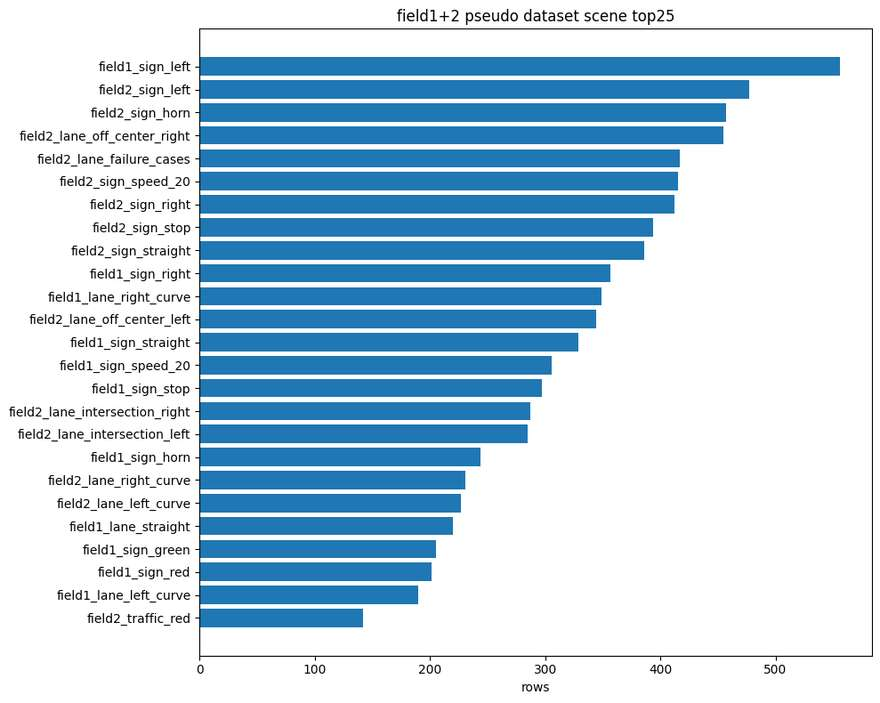

In [6]:
scene_counts = all_df.groupby(['dataset', 'scene']).size().rename('rows').reset_index()
for dataset in scene_counts['dataset'].unique():
    print('\n', dataset)
    display(scene_counts[scene_counts['dataset'] == dataset].sort_values('rows', ascending=False).head(30))

# field1+2만 scene top 시각화
field12_scene = scene_counts[scene_counts['dataset'] == 'field1+2_pseudo'].sort_values('rows', ascending=False).head(25)
plt.figure(figsize=(10, 8))
plt.barh(field12_scene['scene'][::-1], field12_scene['rows'][::-1])
plt.title('field1+2 pseudo dataset scene top25')
plt.xlabel('rows')
plt.tight_layout()
plt.show()


## 7. 라벨 overlay 샘플 비교

두 dataset에서 train/val/test 샘플을 뽑아 같은 방식으로 `.lines.txt`를 이미지 위에 그림.

목적:

```text
field1+2 pseudo label이 더 깨끗한가?
field3 label이 실제 주행 시야에 더 가까운가?
한쪽 차선/곡선 상황에서 어떤 dataset이 더 자연스러운가?
```


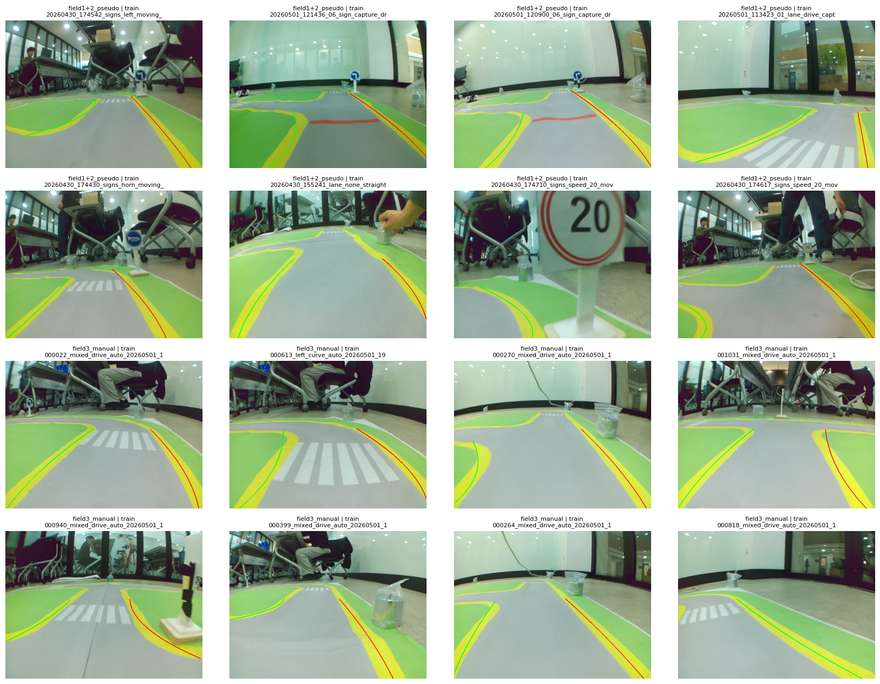

In [7]:
def imread_rgb(path: Path):
    data = np.fromfile(win_long_path(path), dtype=np.uint8)
    image_bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise RuntimeError(f'failed to read image: {path}')
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def draw_lanes(image_path: Path, line_path: Path):
    image = imread_rgb(image_path)
    lanes = read_lanes_abs(line_path)
    colors = [(0, 255, 0), (255, 0, 0), (0, 128, 255), (255, 0, 255)]
    for i, lane in enumerate(lanes[:4]):
        pts = np.array([[round(x), round(y)] for x, y in lane], dtype=np.int32)
        if len(pts) >= 2:
            cv2.polylines(image, [pts], False, colors[i % len(colors)], 4)
    return image


def sample_for_display(dataset_name, n=8, prefer_split=None):
    part = all_df[all_df['dataset'] == dataset_name].copy()
    if prefer_split and (part['split'] == prefer_split).any():
        part = part[part['split'] == prefer_split]
    return part.sample(min(n, len(part)), random_state=11).to_dict('records')

samples = sample_for_display('field1+2_pseudo', n=8, prefer_split='train') + sample_for_display('field3_manual', n=8, prefer_split='train')
cols = 4
rows = math.ceil(len(samples) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.2))
axes = np.array(axes).reshape(-1)

for ax, row in zip(axes, samples):
    root = dataset_root_for(row['dataset'])
    image_path = root / str(row['image_rel']).lstrip('/')
    line_path = root / str(row['line_rel']).lstrip('/')
    try:
        vis = draw_lanes(image_path, line_path)
        ax.imshow(vis)
        ax.set_title(f"{row['dataset']} | {row['split']}\n{Path(row['image_rel']).name[:34]}", fontsize=8)
    except Exception as exc:
        ax.text(0.05, 0.5, str(exc), fontsize=8)
    ax.axis('off')

for ax in axes[len(samples):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 8. Hard case 샘플 비교

라벨이 크게 휘거나 한쪽 차선만 보이는 경우를 따로 봄.

여기서 중요한 것은 “나쁜 라벨”만 찾는 게 아니라, **실제 주행 중 자주 마주칠 hard case가 학습 데이터에 들어 있는지** 확인하는 것임.


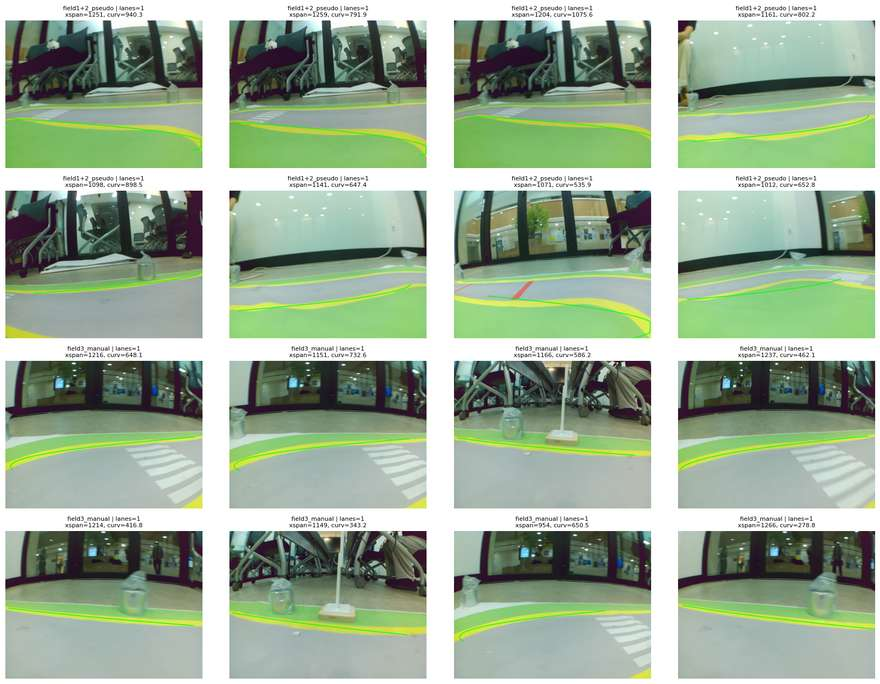

In [8]:
hard_stats = stats_df.copy()
hard_stats['hard_score'] = (
    hard_stats['x_span_max'].rank(pct=True) * 0.35 +
    hard_stats['curvature_max'].rank(pct=True) * 0.35 +
    (hard_stats['lane_count_lines'] == 1).astype(float) * 0.30
)

hard_samples = []
for dataset in ['field1+2_pseudo', 'field3_manual']:
    part = hard_stats[hard_stats['dataset'] == dataset].sort_values('hard_score', ascending=False).head(8)
    hard_samples.extend(part.to_dict('records'))

cols = 4
rows = math.ceil(len(hard_samples) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.2))
axes = np.array(axes).reshape(-1)

for ax, row in zip(axes, hard_samples):
    root = dataset_root_for(row['dataset'])
    image_path = root / str(row['image_rel']).lstrip('/')
    line_path = root / str(row['line_rel']).lstrip('/')
    try:
        vis = draw_lanes(image_path, line_path)
        ax.imshow(vis)
        ax.set_title(f"{row['dataset']} | lanes={row['lane_count_lines']}\nxspan={row['x_span_max']:.0f}, curv={row['curvature_max']:.1f}", fontsize=8)
    except Exception as exc:
        ax.text(0.05, 0.5, str(exc), fontsize=8)
    ax.axis('off')

for ax in axes[len(hard_samples):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 9. 비교 결과 저장

다음 fine-tuning 설계에서 쓸 수 있게 요약 JSON을 저장함.


In [9]:
comparison = {
    'field12_root': str(FIELD12_ROOT),
    'field3_root': str(FIELD3_ROOT),
    'field12_rows': int(len(field12_df)),
    'field3_rows': int(len(field3_df)),
    'field12_split_counts': {str(k): int(v) for k, v in field12_df['split'].value_counts().items()},
    'field3_split_counts': {str(k): int(v) for k, v in field3_df['split'].value_counts().items()},
    'field12_lane_count': {str(k): int(v) for k, v in stats_df[stats_df['dataset'] == 'field1+2_pseudo']['lane_count_lines'].value_counts().sort_index().items()},
    'field3_lane_count': {str(k): int(v) for k, v in stats_df[stats_df['dataset'] == 'field3_manual']['lane_count_lines'].value_counts().sort_index().items()},
    'outputs': {
        'normalized_manifest': str(OUT_DIR / 'combined_normalized_manifest.csv'),
        'line_geometry_stats': str(OUT_DIR / 'line_geometry_stats.csv'),
        'comparison_summary_table': str(OUT_DIR / 'comparison_summary_table.csv'),
    },
    'interpretation_placeholder': 'Run notebook and write decision in final markdown cell.',
}
comparison_path = OUT_DIR / 'comparison_summary.json'
comparison_path.write_text(json.dumps(comparison, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(comparison, indent=2, ensure_ascii=False))


{
  "field12_root": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\30_pipelines\\culane_pseudo_dataset_builder\\datasets\\map_culane_field1_field2_train_component_poly",
  "field3_root": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\datasets\\field3_v1",
  "field12_rows": 9052,
  "field3_rows": 1679,
  "field12_split_counts": {
    "train": 7241,
    "val": 1811
  },
  "field3_split_counts": {
    "train": 1378,
    "val": 164,
    "test": 137
  },
  "field12_lane_count": {
    "1": 1368,
    "2": 7684
  },
  "field3_lane_count": {
    "1": 441,
    "2": 1238
  },
  "outputs": {
    "normalized_manifest": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\review_outputs\\04_dataset_compare_field12_vs_field3\\combined_normalized_manifest.csv",
    "line_geometry_stats": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSyst

## 10. 실행 후 판단 메모

실행 결과 field1+2와 field3 모두 `.lines.txt`를 정상적으로 읽었음. 이전에 field1+2가 `lane_count=0`으로 보이던 문제는 Windows 긴 경로 문제였고, `win_long_path()` 패치 후 정상화됨.

핵심 수치:

```text
field1+2 pseudo
- rows: 9052
- train/val/test: 7241 / 1811 / 0
- 1-lane / 2-lane: 1368 / 7684
- point_total mean/median: 112.0 / 117
- x_span_max mean/p90: 504 / 798
- y_span_max mean/median: 402 / 414
- curvature median/p90: 84 / 205

field3 manual
- rows: 1679
- train/val/test: 1378 / 164 / 137
- 1-lane / 2-lane: 441 / 1238
- point_total mean/median: 121.4 / 123
- x_span_max mean/p90: 550 / 941
- y_span_max mean/median: 474 / 522
- curvature median/p90: 30 / 250
```

해석:

```text
field1+2는 데이터 수가 많고 scene이 다양함. 하지만 HSV/component_poly 기반 pseudo label이라 실제 주행 시야 분포와 다소 섞여 있음.
field3는 수량은 적지만 실제 주행 중 수집된 데이터라 주행 시야에 더 직접적임.
field3는 y_span이 더 길고 1-lane 비율도 더 높아, 실제 카메라 주행에서 보이는 한쪽 차선/곡선/가까운 차선 상황을 더 많이 포함함.
field3의 curvature 중앙값은 낮아 전반적으로 더 매끄러운 라벨이 많지만, p90은 더 높아 일부 hard case도 포함함.
```

다음 fine-tuning 전략:

```text
1순위: 기존 field1+2 full fine-tuned model에서 field3_v1로 추가 fine-tuning
- 이유: field1+2의 양과 기본 도메인 적응을 버리지 않으면서, field3의 실제 주행 분포를 입힐 수 있음.

2순위: pretrained ResNet18_CULane에서 field3_v1만 fine-tuning
- 이유: field3 데이터 자체의 효과를 분리해서 확인하는 baseline 역할.

3순위: field1+2 + field3 combined dataset으로 처음부터 fine-tuning
- 이유: 최종 후보가 될 수 있지만, 데이터셋 결합/가중치 문제 때문에 바로 첫 실험으로 가기엔 변수가 많음.
```

따라서 다음 노트북은 `05_finetune_experiment_plan_and_colab_pack.ipynb`로 가고, 우선 Colab에서 아래 두 실험을 준비하는 것이 적절함.

```text
A. ResNet18_CULane.pth → field3_v1 fine-tuning
B. field1+2 finetune_v1 best.pth → field3_v1 추가 fine-tuning
```
